In [16]:
library(data.table)
library(ggplot2)
library(dplyr)

In [64]:
DEGs = fread('DEresults_stageE8.5_tdTom_corrFalse_pseudobulk.txt.gz')[,celltype:=variable]

In [29]:
keep = unique(DEGs$celltype)

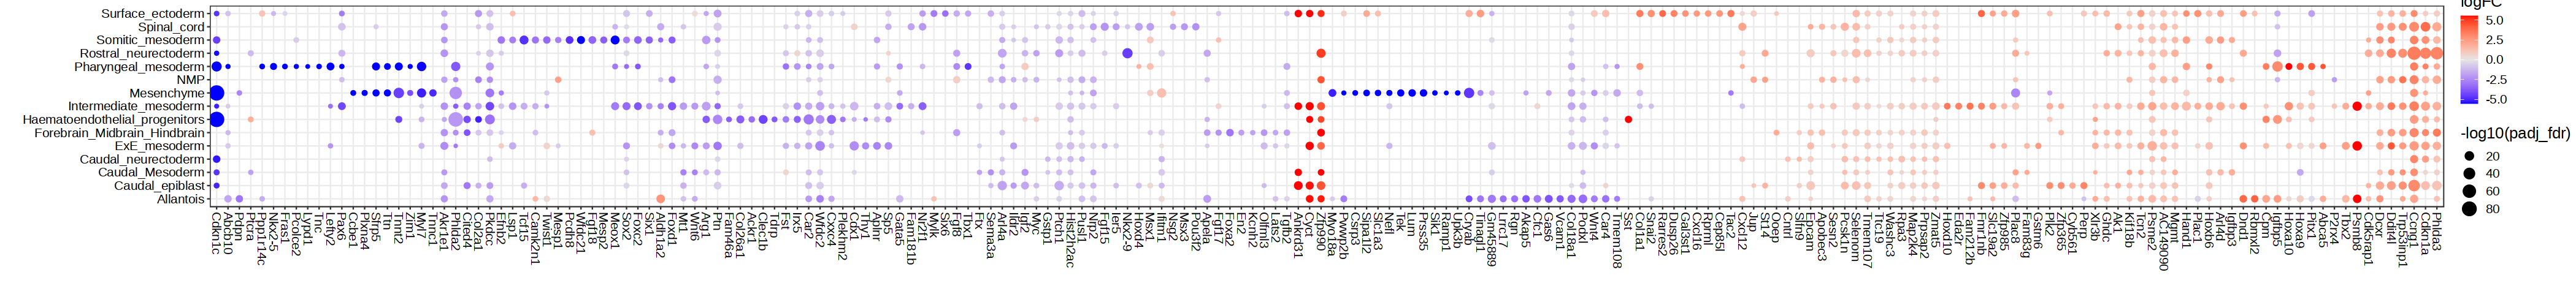

In [88]:
features = unique(DEGs[padj_fdr<0.05 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 20), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.95
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=35, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

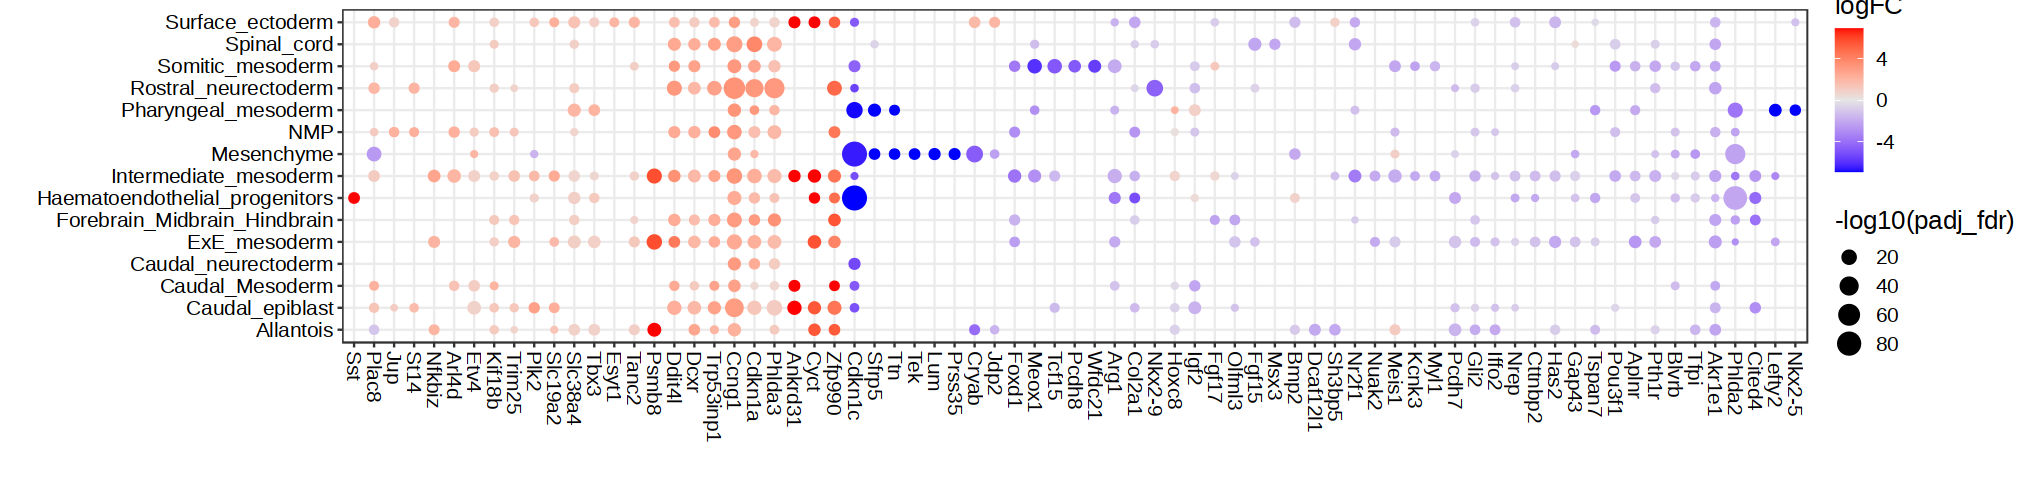

In [109]:
logFC_threshold = 2
top_x = 4
features = c(unique(DEGs[padj_fdr<0.05 & abs(logFC) > logFC_threshold] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, top_x), by=celltype] %>% .$gene,
             unique(DEGs[padj_fdr<0.05 & abs(logFC) > logFC_threshold] %>% .[order(abs(logFC)), ]) %>% .[,head(.SD, top_x), by=celltype] %>% .$gene)

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.95
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=length(features)/7, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))